# 1. Import Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report

# 2. Load & Clean Dataset

In [4]:
# Load without header
df = pd.read_csv("dataset_35_dermatology (1).csv", header=None)

# Drop the first row (text headers)
df = df.drop(index=0)

# Assign column names
columns = [
    'erythema', 'scaling', 'definite_borders', 'itching', 'koebner_phenomenon', 'polygonal_papules',
    'follicular_papules', 'oral_mucosal_involvement', 'knee_and_elbow_involvement', 'scalp_involvement',
    'family_history', 'melanin_incontinence', 'eosinophils_infiltrate', 'PNL_infiltrate',
    'fibrosis_papillary_dermis', 'exocytosis', 'acanthosis', 'hyperkeratosis', 'parakeratosis',
    'clubbing_rete_ridges', 'elongation_rete_ridges', 'thinning_suprapapillary_epidermis',
    'spongiform_pustule', 'munro_microabcess', 'focal_hypergranulosis', 'granular_layer_disappearance',
    'vacuolisation_damage_basal_layer', 'spongiosis', 'saw_tooth_retes', 'follicular_horn_plug',
    'perifollicular_parakeratosis', 'inflammatory_monoluclear_infiltrate', 'band_like_infiltrate',
    'age', 'target'
]
df.columns = columns

# Replace '?' with NaN and clean
df.replace('?', np.nan, inplace=True)
df.dropna(inplace=True)
df = df.astype(float)

# 3. Exploratory Data Analysis (EDA)

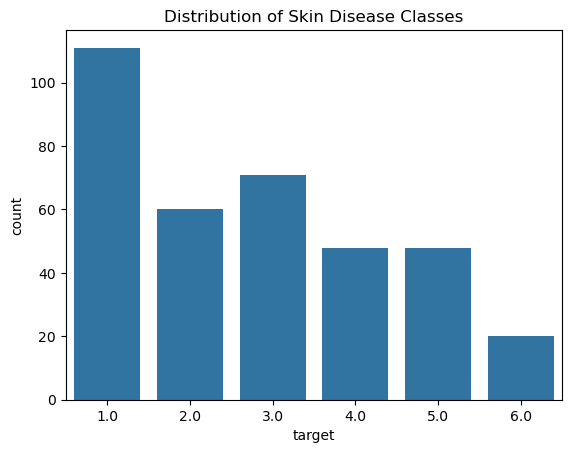

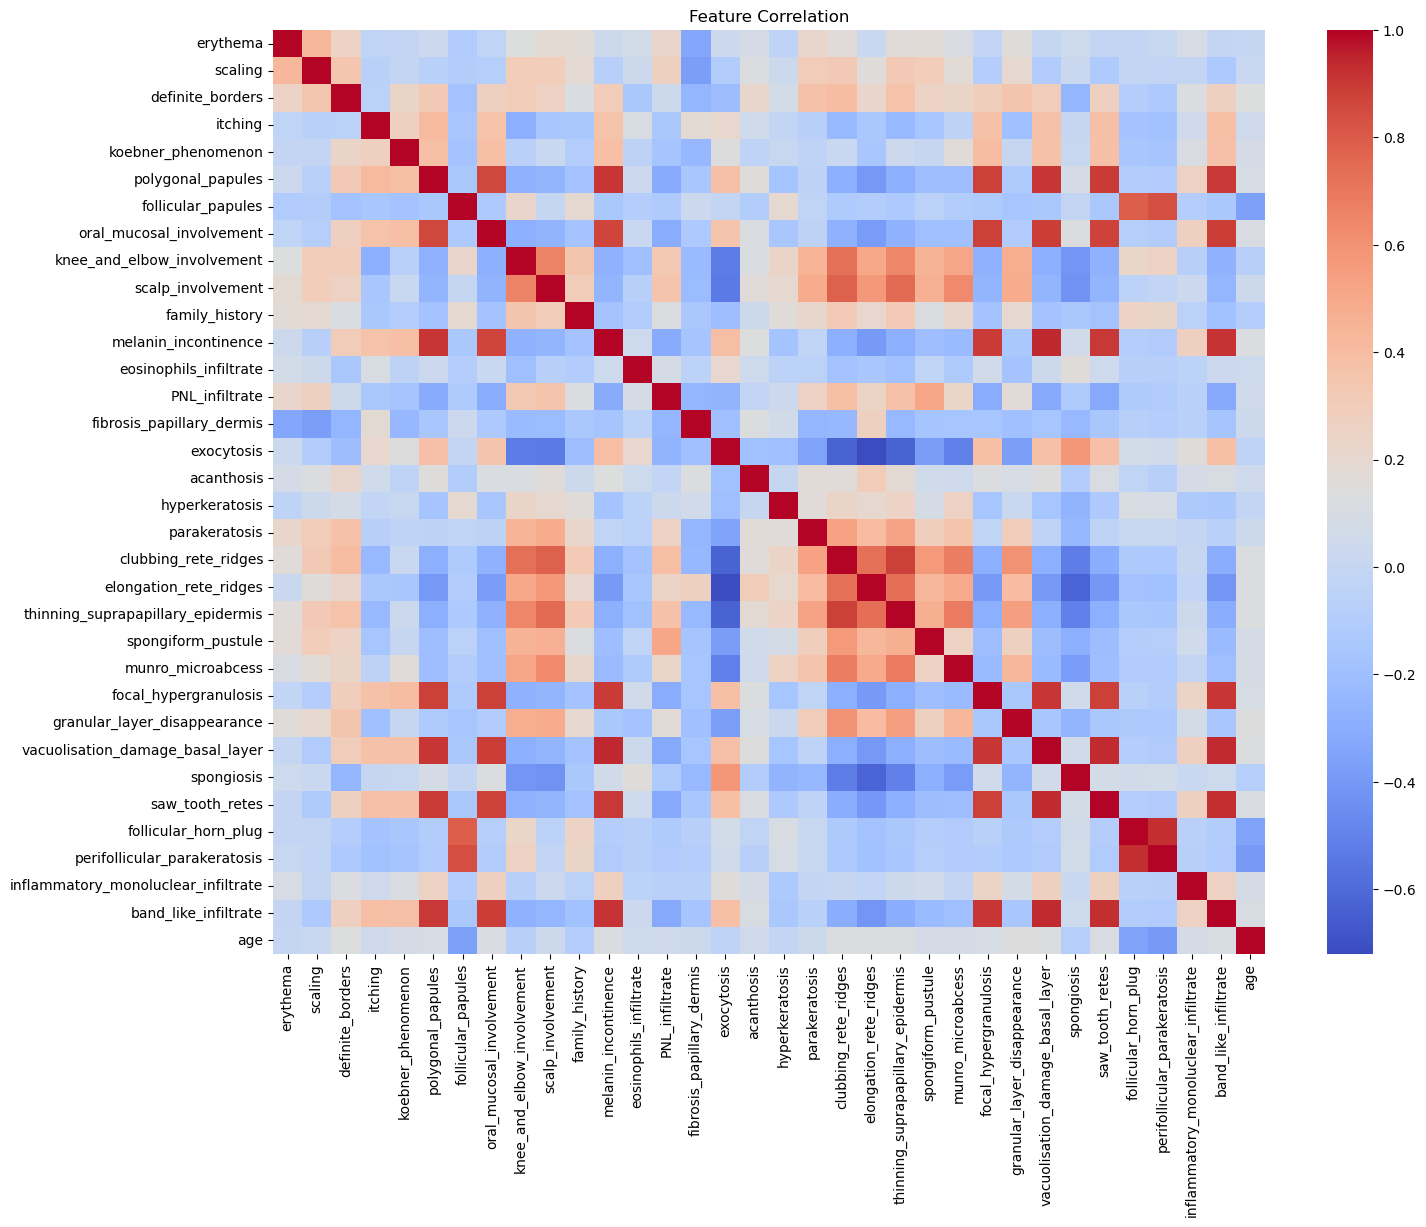

In [6]:
# Target distribution
sns.countplot(x='target', data=df)
plt.title("Distribution of Skin Disease Classes")
plt.show()

# Correlation heatmap
plt.figure(figsize=(16, 12))
sns.heatmap(df.drop('target', axis=1).corr(), cmap="coolwarm")
plt.title("Feature Correlation")
plt.show()

# 4. Preprocessing

In [8]:
X = df.drop("target", axis=1)
y = df["target"]

# Normalize
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

#  5. Train and Evaluate Models

In [10]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "SVM": SVC(),
    "KNN": KNeighborsClassifier()
}

model_results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    model_results[name] = acc
    print(f"--- {name} ---")
    print("Accuracy:", acc)
    print(classification_report(y_test, y_pred))

--- Logistic Regression ---
Accuracy: 0.9861111111111112
              precision    recall  f1-score   support

         1.0       1.00      1.00      1.00        22
         2.0       1.00      0.92      0.96        12
         3.0       1.00      1.00      1.00        14
         4.0       0.91      1.00      0.95        10
         5.0       1.00      1.00      1.00        10
         6.0       1.00      1.00      1.00         4

    accuracy                           0.99        72
   macro avg       0.98      0.99      0.98        72
weighted avg       0.99      0.99      0.99        72

--- Decision Tree ---
Accuracy: 0.9305555555555556
              precision    recall  f1-score   support

         1.0       0.96      1.00      0.98        22
         2.0       0.83      0.83      0.83        12
         3.0       0.93      1.00      0.97        14
         4.0       1.00      0.90      0.95        10
         5.0       1.00      1.00      1.00        10
         6.0       0.67 

# 6. Model Comparison

                 Model  Accuracy
0  Logistic Regression  0.986111
2        Random Forest  0.986111
3                  SVM  0.986111
4                  KNN  0.944444
1        Decision Tree  0.930556


C:\Users\imran\AppData\Local\Temp\ipykernel_13940\1274064386.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Accuracy", y="Model", data=results_df, palette="crest")


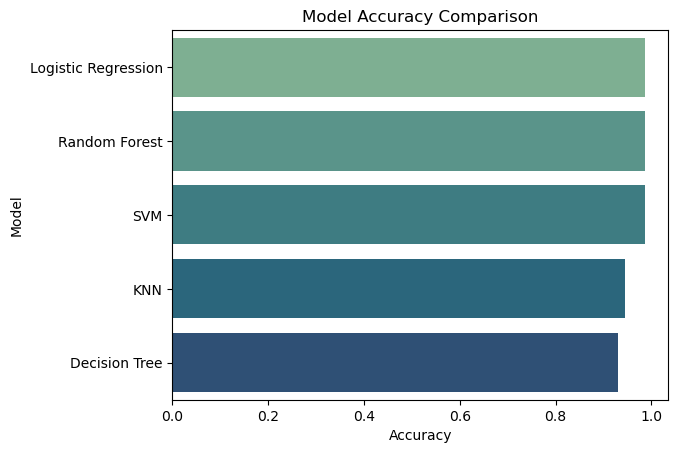

In [12]:
results_df = pd.DataFrame(list(model_results.items()), columns=["Model", "Accuracy"])
results_df = results_df.sort_values(by="Accuracy", ascending=False)

# Display table
print(results_df)

# Plot comparison
sns.barplot(x="Accuracy", y="Model", data=results_df, palette="crest")
plt.title("Model Accuracy Comparison")
plt.show()

# 7. Feature Importance & Doctor Suggestions

Top 10 Important Features:
                              Feature  Importance
19               clubbing_rete_ridges    0.114784
14          fibrosis_papillary_dermis    0.080599
21  thinning_suprapapillary_epidermis    0.078403
32               band_like_infiltrate    0.059684
4                  koebner_phenomenon    0.055455
27                         spongiosis    0.053002
20             elongation_rete_ridges    0.042358
28                    saw_tooth_retes    0.036614
13                     PNL_infiltrate    0.034194
24              focal_hypergranulosis    0.033597


C:\Users\imran\AppData\Local\Temp\ipykernel_13940\790793578.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Importance", y="Feature", data=feature_importance_df.head(10), palette="flare")


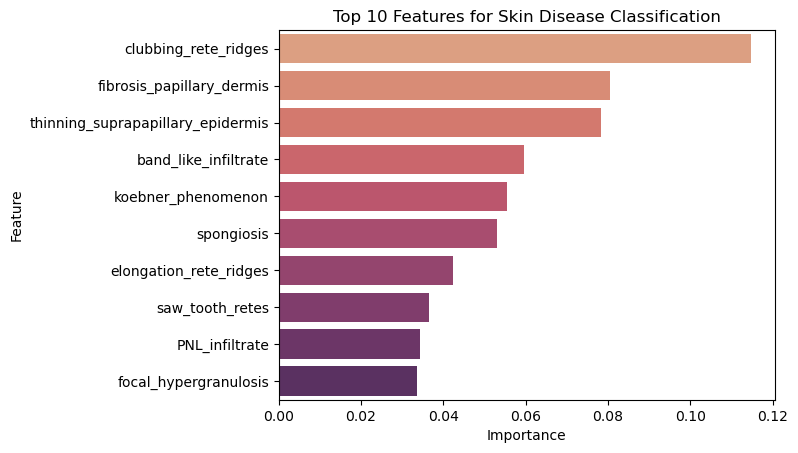

In [14]:
rf_model = models["Random Forest"]
importances = rf_model.feature_importances_

feature_importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

print("Top 10 Important Features:")
print(feature_importance_df.head(10))

# Plot
sns.barplot(x="Importance", y="Feature", data=feature_importance_df.head(10), palette="flare")
plt.title("Top 10 Features for Skin Disease Classification")
plt.show()

# 8. Challenges Faced

### Challenges Faced and Solutions

#### 1. **Header Issue**: The dataset had header text as the first row dropped the row and manually assigned column names. 
#### 2. **Missing Values**: Handled '?' by converting to NaN and dropping missing rows.
#### 3. **Data Type Issues**: Used `.astype(float)` for clean numeric processing.
#### 4. **Model Selection**: Trained and compared several models to find the best one.
#### 5. **Interpretability**: Used Random Forests feature importance to suggest relevant clinical features to doctors.

# Conclusion

This project successfully classified skin diseases using various machine learning models. Random Forest achieved the highest accuracy and was selected as the best model. Important features such as scaling, itching, parakeratosis, and acanthosis were identified. These insights can help dermatologists diagnose diseases early with data-driven tools.
